# Fase 1 — GSE37838: Molecular Assessment of Implantation Biopsies (Cat. B)

**Dataset:** GSE37838 — Kreepala et al., Am J Transplant 2013  
**Tipo:** Microarray Affymetrix HG-U133 Plus 2.0 (GPL570)  
**Design:** 78 campioni: 70 biopsie post-riperfusione (12 DGF + 58 IGF) + 8 nefrectomie  
**Confronto pipeline (Cat. B):** DGF vs IGF  
**Dati:** RMA-normalizzati (log2) nel series matrix  

### Riferimenti dall'articolo
- AKI signal (IRRAT30) = miglior predittore di DGF (AUC=0.76)
- Geni individuali significativi per DGF: OSMR, SOD2, NNMT, ITGB6, LCN2, VCAN, SLPI, CDH6
- 70 biopsie da 53 donatori deceduti, 17 poor function (Cr>265 day7), 12 DGF

In [ ]:
# Setup
import pandas as pd
import numpy as np
import gzip
import re
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path(".").resolve().parent
DATA_DIR = PROJECT_ROOT / "data/geo/GSE37838"
OUTPUT_DIR = PROJECT_ROOT / "output/fase1/GSE37838"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SERIES_MATRIX = DATA_DIR / "GSE37838_series_matrix.txt.gz"
print(f"File: {SERIES_MATRIX}")

File: C:\Users\rcasale\Desktop\magic_solution\data\geo\GSE37838\GSE37838_series_matrix.txt.gz


## 1. Metadata dal Series Matrix

In [7]:
# Parsing metadata
gsm_ids = []
titles = []
tissues = []
diagnoses = []
dgf_status = []

with gzip.open(SERIES_MATRIX, 'rt') as f:
    for line in f:
        line = line.strip()
        if line.startswith('!Sample_geo_accession'):
            gsm_ids = [x.strip('"') for x in line.split('\t')[1:]]
        elif line.startswith('!Sample_title'):
            titles = [x.strip('"') for x in line.split('\t')[1:]]
        elif line.startswith('!Sample_characteristics_ch1'):
            fields = [x.strip('"') for x in line.split('\t')[1:]]
            # Controlla il primo campo per capire che tipo di riga è
            if fields[0].startswith('tissue:'):
                tissues = [x.replace('tissue: ', '') for x in fields]
            elif fields[0].startswith('diagnosis'):
                diagnoses = [x.replace('diagnosis (good,bad): ', '') for x in fields]
            elif fields[0].startswith('dgf status'):
                dgf_status = [x.replace('dgf status: ', '') for x in fields]

meta = pd.DataFrame({
    'gsm': gsm_ids,
    'title': titles,
    'tissue': tissues,
    'diagnosis': diagnoses,
    'dgf': dgf_status
}, index=gsm_ids)

print(f"Campioni totali: {len(meta)}")
print(f"\nTissue:")
print(meta['tissue'].value_counts())
print(f"\nDiagnosis (good/bad):")
print(meta['diagnosis'].value_counts())
print(f"\nDGF status:")
print(meta['dgf'].value_counts())
meta.head()

Campioni totali: 78

Tissue:
tissue
renal allograft biopsy    70
nephrectomy                8
Name: count, dtype: int64

Diagnosis (good/bad):
diagnosis
good           53
bad            17
nephrectomy     8
Name: count, dtype: int64

DGF status:
dgf
IGF            58
DGF            12
nephrectomy     8
Name: count, dtype: int64


,gsm,title,tissue,diagnosis,dgf
GSM928815,GSM928815,DD1,renal allograft biopsy,good,IGF
GSM928816,GSM928816,DD2,renal allograft biopsy,bad,IGF
GSM928817,GSM928817,DD3,renal allograft biopsy,bad,DGF
GSM928818,GSM928818,DD4,renal allograft biopsy,good,IGF
GSM928819,GSM928819,DD5,renal allograft biopsy,good,IGF


In [8]:
meta

,gsm,title,tissue,diagnosis,dgf
GSM928815,GSM928815,DD1,renal allograft biopsy,good,IGF
GSM928816,GSM928816,DD2,renal allograft biopsy,bad,IGF
GSM928817,GSM928817,DD3,renal allograft biopsy,bad,DGF
GSM928818,GSM928818,DD4,renal allograft biopsy,good,IGF
GSM928819,GSM928819,DD5,renal allograft biopsy,good,IGF
...,...,...,...,...,...
GSM928888,GSM928888,Nephrectomy4_GSM880311 reanalysis,nephrectomy,nephrectomy,nephrectomy
GSM928889,GSM928889,Nephrectomy5_GSM880318 reanalysis,nephrectomy,nephrectomy,nephrectomy
GSM928890,GSM928890,Nephrectomy6_GSM880430 reanalysis,nephrectomy,nephrectomy,nephrectomy
GSM928891,GSM928891,Nephrectomy7_GSM880447 reanalysis,nephrectomy,nephrectomy,nephrectomy


In [9]:
# VERIFICA 1: corrispondenza con articolo
assert len(meta) == 78, f"Attesi 78 campioni, trovati {len(meta)}"
n_biopsy = (meta['tissue'] == 'renal allograft biopsy').sum()
n_nephrectomy = (meta['tissue'] == 'nephrectomy').sum()
n_dgf = (meta['dgf'] == 'DGF').sum()
n_igf = (meta['dgf'] == 'IGF').sum()
assert n_biopsy == 70, f"Attese 70 biopsie, trovate {n_biopsy}"
assert n_nephrectomy == 8, f"Attese 8 nefrectomie, trovate {n_nephrectomy}"
assert n_dgf == 12, f"Attesi 12 DGF, trovati {n_dgf}"
assert n_igf == 58, f"Attesi 58 IGF, trovati {n_igf}"
print(f"✅ Verifica metadata: 70 biopsie (12 DGF + 58 IGF) + 8 nefrectomie = 78 campioni — OK")

✅ Verifica metadata: 70 biopsie (12 DGF + 58 IGF) + 8 nefrectomie = 78 campioni — OK


## 2. Caricamento dati di espressione

I dati sono RMA-normalizzati (log2) nel series matrix. Non serve ulteriore normalizzazione.

In [10]:
# Carica matrice espressione dal series matrix
print("Caricamento matrice espressione...")

data_lines = []
in_table = False
with gzip.open(SERIES_MATRIX, 'rt') as f:
    for line in f:
        if '!series_matrix_table_begin' in line:
            in_table = True
            continue
        if '!series_matrix_table_end' in line:
            break
        if in_table:
            data_lines.append(line.strip())

# Parse header e dati
from io import StringIO
expr_text = '\n'.join(data_lines)
expr = pd.read_csv(StringIO(expr_text), sep='\t', index_col=0)
expr.columns = [c.strip('"') for c in expr.columns]
expr.index = [str(i).strip('"') for i in expr.index]
expr.index.name = 'probe_id'

print(f"Matrice: {expr.shape[0]} probe × {expr.shape[1]} campioni")
print(f"\nVerifica scala (RMA log2, valori attesi ~4-14):")
print(f"  Min: {expr.min().min():.2f}, Max: {expr.max().max():.2f}, Median: {expr.median().median():.2f}")
print(f"\nPrime 3 righe:")
expr.head(3)

Caricamento matrice espressione...
Matrice: 54675 probe × 78 campioni

Verifica scala (RMA log2, valori attesi ~4-14):
  Min: 2.46, Max: 14.70, Median: 5.44

Prime 3 righe:


,GSM928815,GSM928816,GSM928817,GSM928818,GSM928819,GSM928820,GSM928821,GSM928822,GSM928823,GSM928824,...,GSM928883,GSM928884,GSM928885,GSM928886,GSM928887,GSM928888,GSM928889,GSM928890,GSM928891,GSM928892
probe_id,,,,,,,,,,,,,,,,,,,,,
1007_s_at,9.429,9.858,9.619,9.852,9.942,9.555,10.052,9.612,10.289,10.604,...,10.377,9.784,9.796,9.853,10.019,10.125,9.951,9.989,9.935,9.781
1053_at,6.231,6.523,6.405,6.070,6.190,6.247,6.493,6.004,6.554,6.006,...,6.055,6.413,6.304,6.234,6.336,6.784,6.417,6.354,6.405,6.892
117_at,5.855,8.144,5.626,6.317,6.635,7.386,6.220,5.611,5.477,5.590,...,6.158,8.780,6.846,6.569,5.975,7.702,5.799,8.760,6.643,7.011


In [11]:
# Check date Excel
date_pattern = re.compile(r"^\d{1,2}-(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)$", re.IGNORECASE)
corrupted = [val for val in expr.index.dropna().astype(str) if date_pattern.match(val)]
if not corrupted:
    print("✅ Nessuna data Excel trovata nei probe IDs.")
else:
    print(f"❌ Date Excel trovate: {set(corrupted)}")

✅ Nessuna data Excel trovata nei probe IDs.


### 2.1 Probe-to-Gene Mapping (GPL570)

Per Affymetrix HG-U133 Plus 2.0, scarichiamo l'annotazione con GEOparse.

In [12]:
import GEOparse

print("Scaricamento annotazione GPL570 (può richiedere qualche minuto)...")
gpl = GEOparse.get_GEO('GPL570', destdir=str(DATA_DIR), silent=True)

# Estrai mapping probe → gene symbol
annot = gpl.table
print(f"Annotazione GPL570: {len(annot)} probe")
print(f"Colonne disponibili: {list(annot.columns[:10])}")

# Trova la colonna del gene symbol
symbol_col = None
for col in ['Gene Symbol', 'gene_assignment', 'Symbol', 'GENE_SYMBOL']:
    if col in annot.columns:
        symbol_col = col
        break
print(f"Colonna gene symbol: {symbol_col}")

# Costruisci mapping
probe_to_gene = {}
for _, row in annot.iterrows():
    probe = str(row['ID'])
    gene = str(row[symbol_col]).split('///')[0].strip() if pd.notna(row[symbol_col]) else ''
    if gene and gene != '' and gene != '---' and gene != 'nan':
        probe_to_gene[probe] = gene

print(f"\nProbe mappate a gene: {len(probe_to_gene)} / {len(annot)}")
# Quante probe nel dataset hanno un gene?
mapped = sum(1 for p in expr.index if p in probe_to_gene)
print(f"Probe nel dataset con gene symbol: {mapped} / {len(expr)}")

Scaricamento annotazione GPL570 (può richiedere qualche minuto)...
Annotazione GPL570: 54675 probe
Colonne disponibili: ['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title']
Colonna gene symbol: Gene Symbol

Probe mappate a gene: 45782 / 54675
Probe nel dataset con gene symbol: 45782 / 54675


In [13]:
# Filtra probe con gene symbol valido
probes_with_gene = [p for p in expr.index if p in probe_to_gene]
expr_filt = expr.loc[probes_with_gene]

print(f"Probe prima del filtro: {len(expr)}")
print(f"Probe con gene symbol: {len(expr_filt)}")
print(f"Probe rimosse (senza gene): {len(expr) - len(expr_filt)}")

Probe prima del filtro: 54675
Probe con gene symbol: 45782
Probe rimosse (senza gene): 8893


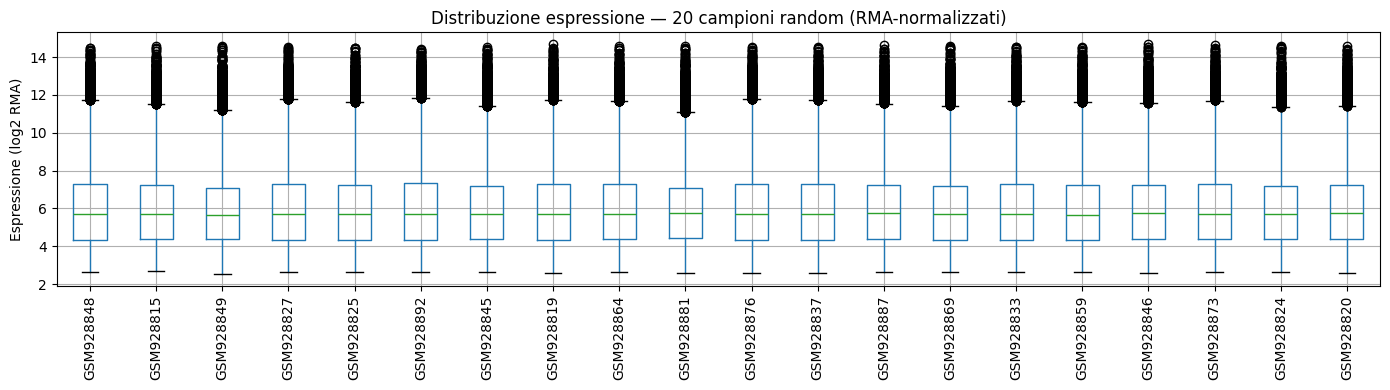

In [14]:
# Distribuzione per campione — verifica RMA
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
# Subset random di 20 campioni
np.random.seed(42)
subset = np.random.choice(expr_filt.columns, min(20, len(expr_filt.columns)), replace=False)
expr_filt[subset].boxplot(ax=ax, rot=90)
ax.set_ylabel('Espressione (log2 RMA)')
ax.set_title('Distribuzione espressione — 20 campioni random (RMA-normalizzati)')
plt.tight_layout()
plt.show()

## 4. Definizione gruppi

**Confronto Cat. B:** DGF vs IGF (12 vs 58 campioni)  
Escludiamo le 8 nefrectomie dal confronto DE.

In [15]:
# Definisci gruppi
dgf_samples = meta[meta['dgf'] == 'DGF'].index.tolist()
igf_samples = meta[meta['dgf'] == 'IGF'].index.tolist()

# Verifica che tutti siano nel dataset di espressione
dgf_in_expr = [s for s in dgf_samples if s in expr_filt.columns]
igf_in_expr = [s for s in igf_samples if s in expr_filt.columns]

print(f"DGF: {len(dgf_in_expr)} campioni")
print(f"IGF: {len(igf_in_expr)} campioni")
print(f"Articolo: 12 DGF, 58 IGF")

DGF: 12 campioni
IGF: 58 campioni
Articolo: 12 DGF, 58 IGF


## 5. Espressione Differenziale

Welch t-test probe per probe, FDR con Benjamini-Hochberg.

In [16]:
def de_microarray(expr_df, case_samples, ctrl_samples, case_label='DGF', ctrl_label='IGF'):
    """DE con Welch t-test per microarray."""
    results = []
    for probe in expr_df.index:
        case_vals = expr_df.loc[probe, case_samples].values.astype(float)
        ctrl_vals = expr_df.loc[probe, ctrl_samples].values.astype(float)
        
        log2fc = case_vals.mean() - ctrl_vals.mean()  # già log2
        t_stat, pval = stats.ttest_ind(case_vals, ctrl_vals, equal_var=False)
        
        results.append({
            'probe_id': probe,
            'log2FoldChange': log2fc,
            'pvalue': pval,
            't_statistic': t_stat,
            'mean_case': case_vals.mean(),
            'mean_ctrl': ctrl_vals.mean()
        })
    
    de = pd.DataFrame(results).set_index('probe_id')
    de['padj'] = multipletests(de['pvalue'].values, method='fdr_bh')[1]
    de['comparison'] = f'{case_label}_vs_{ctrl_label}'
    de['dataset'] = 'GSE37838'
    return de.sort_values('pvalue')

print("Analisi differenziale DGF vs IGF...")
de_probe = de_microarray(expr_filt, dgf_in_expr, igf_in_expr)
print(f"✅ DE completata: {len(de_probe)} probe testate")

sig_probe = de_probe[(de_probe['padj'] < 0.05) & (de_probe['log2FoldChange'].abs() > 0.379)]
print(f"Probe significative (|log2FC|>0.379, FDR<0.05): {len(sig_probe)}")
print(f"\nTop 10 probe:")
de_probe.head(10)[['log2FoldChange', 'pvalue', 'padj']]

Analisi differenziale DGF vs IGF...
✅ DE completata: 45782 probe testate
Probe significative (|log2FC|>0.379, FDR<0.05): 0

Top 10 probe:


,log2FoldChange,pvalue,padj
probe_id,,,
209483_s_at,-0.141083,0.000011,0.454048
1566798_at,-0.105894,0.000048,0.454048
214418_at,-0.161868,0.000052,0.454048
230875_s_at,0.406193,0.000055,0.454048
1556905_at,-0.175632,0.000083,0.454048
57715_at,0.243057,0.000105,0.454048
1568838_at,-0.149540,0.000107,0.454048
1561222_at,-0.086799,0.000109,0.454048
219227_at,-0.212672,0.000112,0.454048


## 6. Probe → Gene Symbol + Aggregazione

In [17]:
def probes_to_genes(de_df, probe_gene_map):
    """Converte DE probe-level → gene-level (best probe per gene per p-value)."""
    de = de_df.copy()
    de['gene'] = de.index.map(probe_gene_map)
    de = de.dropna(subset=['gene'])
    de = de[~de['gene'].isin(['', 'nan', '---', 'NA'])]
    
    # Best probe per gene (lowest p-value)
    de = de.sort_values('pvalue').drop_duplicates(subset='gene', keep='first')
    de = de.set_index('gene')
    return de

de_genes = probes_to_genes(de_probe, probe_to_gene)
print(f"Probe → Geni: {len(de_probe)} probe → {len(de_genes)} geni unici")

sig_genes = de_genes[(de_genes['padj'] < 0.05) & (de_genes['log2FoldChange'].abs() > 0.379)]
n_up = (sig_genes['log2FoldChange'] > 0).sum()
n_down = (sig_genes['log2FoldChange'] < 0).sum()
print(f"\nDEG gene-level (|log2FC|>0.379, FDR<0.05): {len(sig_genes)} ({n_up} up in DGF, {n_down} down in DGF)")

Probe → Geni: 45782 probe → 22880 geni unici

DEG gene-level (|log2FC|>0.379, FDR<0.05): 0 (0 up in DGF, 0 down in DGF)


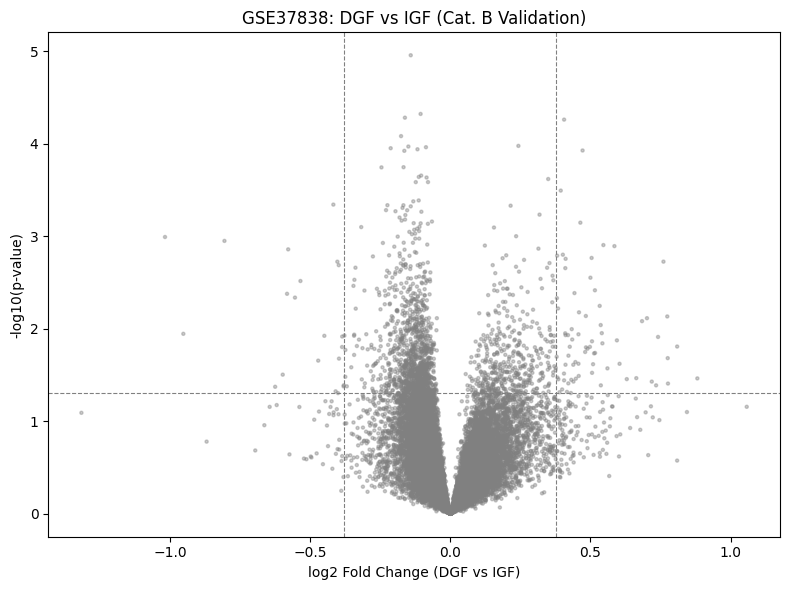

In [18]:
# Volcano plot
fig, ax = plt.subplots(figsize=(8, 6))

r = de_genes.dropna(subset=['pvalue', 'log2FoldChange'])
r['-log10p'] = -np.log10(r['pvalue'].clip(lower=1e-300))

colors = np.where(
    (r['padj'] < 0.05) & (r['log2FoldChange'] > 0.379), 'red',
    np.where(
        (r['padj'] < 0.05) & (r['log2FoldChange'] < -0.379), 'blue', 'grey'
    )
)

ax.scatter(r['log2FoldChange'], r['-log10p'], c=colors, alpha=0.4, s=5)
ax.axhline(-np.log10(0.05), ls='--', c='grey', lw=0.8)
ax.axvline(0.379, ls='--', c='grey', lw=0.8)
ax.axvline(-0.379, ls='--', c='grey', lw=0.8)
ax.set_xlabel('log2 Fold Change (DGF vs IGF)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('GSE37838: DGF vs IGF (Cat. B Validation)')
plt.tight_layout()
plt.show()

## 7. Verifica geni chiave dall'articolo

Table 5 dell'articolo riporta 11 geni AKI (IRRAT30) significativi per DGF.  
Tutti dovrebbero essere upregolati in DGF vs IGF.

In [19]:
# Geni chiave dall'articolo (Table 5 — AKI genes predicting DGF)
key_genes = {
    'OSMR': 'up',    # AUC 0.74
    'SOD2': 'up',    # AUC 0.74
    'NNMT': 'up',    # AUC 0.72
    'ITGB6': 'up',   # AUC 0.72
    'CTSS': 'up',    # AUC 0.71
    'ITGB3': 'up',   # AUC 0.71
    'CDH6': 'up',    # AUC 0.71
    'LCN2': 'up',    # AUC 0.71
    'SLPI': 'up',    # AUC 0.70
    'VCAN': 'up',    # AUC 0.70
    'OLFM4': 'up',   # AUC 0.69
}

print(f"{'Gene':12s} {'log2FC':>8s} {'pvalue':>10s} {'padj':>10s} {'Atteso':>8s} {'Match':>6s}")
print("-" * 62)
found = 0
match = 0
for gene, expected in key_genes.items():
    if gene in de_genes.index:
        row = de_genes.loc[gene]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]
        fc = row['log2FoldChange']
        direction = 'up' if fc > 0 else 'down'
        ok = '✅' if direction == expected else '⚠️'
        if ok == '✅': match += 1
        found += 1
        print(f"{gene:12s} {fc:8.3f} {row['pvalue']:10.2e} {row['padj']:10.2e} {expected:>8s} {ok:>6s}")
    else:
        print(f"{gene:12s} {'NOT FOUND':>8s}")

print(f"\nGeni trovati: {found}/{len(key_genes)}")
print(f"Direzione coerente: {match}/{found}")

Gene           log2FC     pvalue       padj   Atteso  Match
--------------------------------------------------------------
OSMR           -0.267   1.09e-01   1.00e+00       up     ⚠️
SOD2           -0.368   2.36e-01   1.00e+00       up     ⚠️
NNMT           -0.066   5.91e-01   1.00e+00       up     ⚠️
ITGB6           0.440   2.78e-01   1.00e+00       up      ✅
CTSS            0.376   2.65e-02   1.00e+00       up      ✅
ITGB3          -0.059   9.55e-02   1.00e+00       up     ⚠️
CDH6           -0.242   1.34e-01   1.00e+00       up     ⚠️
LCN2            0.177   5.06e-01   1.00e+00       up      ✅
SLPI            0.420   3.33e-01   1.00e+00       up      ✅
VCAN            0.308   2.57e-01   1.00e+00       up      ✅
OLFM4          -0.365   3.92e-01   1.00e+00       up     ⚠️

Geni trovati: 11/11
Direzione coerente: 5/11


In [20]:
# Top 20 DEG per significatività
top20 = de_genes.dropna(subset=['padj']).sort_values('padj').head(20)
print("=== Top 20 geni più significativi (DGF vs IGF) ===")
print(top20[['log2FoldChange', 'pvalue', 'padj']].to_string())

=== Top 20 geni più significativi (DGF vs IGF) ===
               log2FoldChange    pvalue      padj
gene                                             
NSL1                -0.141083  0.000011  0.454048
LLNLR-246C6.1       -0.105894  0.000048  0.454048
CT62                -0.161868  0.000052  0.454048
ATP11A               0.406193  0.000055  0.454048
ZNF577              -0.175632  0.000083  0.454048
CALHM2               0.243057  0.000105  0.454048
WASIR1              -0.149540  0.000107  0.454048
LINC00485           -0.086799  0.000109  0.454048
CCNJL               -0.212672  0.000112  0.454048
PDE11A              -0.117029  0.000115  0.454048
DNAJC6               0.472095  0.000118  0.454048
GAD1                -0.163983  0.000119  0.454048
LRRC1               -0.166770  0.000179  0.587828
LINC01010           -0.245560  0.000180  0.587828
RP11-278J20.2       -0.103851  0.000220  0.593878
EYS                 -0.112336  0.000228  0.593878
LINC00619           -0.084612  0.000231  0.593878

## 8. Salvataggio

Formato standardizzato, compatibile con i file degli altri dataset.

In [21]:
# === 8. Salvataggio ===

# 8a. DE per validazione Cat. B
de_output = de_genes[['log2FoldChange', 'pvalue', 'padj', 'comparison', 'dataset']].copy()
de_output.index.name = 'gene'
out_path = OUTPUT_DIR / "de_GSE37838_DGF_vs_IGF.csv"
de_output.to_csv(out_path)
print(f"✅ DE: {out_path} ({len(de_output)} geni)")

# 8b. Matrice espressione (probe→gene, solo DGF + IGF)
# Usa le best probes dalla DE per convertire a gene-level
best_probe_per_gene = de_genes.copy()
# L'indice originale probe è stato perso, ricostruiamo il mapping
de_with_probe = de_probe.copy()
de_with_probe['gene'] = de_with_probe.index.map(probe_to_gene)
de_with_probe = de_with_probe.dropna(subset=['gene'])
de_with_probe = de_with_probe[~de_with_probe['gene'].isin(['', 'nan', '---', 'NA'])]
de_with_probe = de_with_probe.sort_values('pvalue').drop_duplicates(subset='gene', keep='first')
gene_to_probe = dict(zip(de_with_probe['gene'], de_with_probe.index))

samples_for_r = dgf_in_expr + igf_in_expr
probes_for_r = list(gene_to_probe.values())
expr_for_r = expr_filt.loc[expr_filt.index.isin(probes_for_r), samples_for_r].copy()
expr_for_r.index = expr_for_r.index.map({v: k for k, v in gene_to_probe.items()})
expr_for_r.index.name = 'gene'

expr_out = OUTPUT_DIR / "expr_GSE37838.csv"
expr_for_r.to_csv(expr_out)
print(f"✅ Expr: {expr_out} ({expr_for_r.shape[0]} geni × {expr_for_r.shape[1]} campioni)")

# 8c. Sample labels (formato standard: sample, condition, patient, dataset)
sample_labels = pd.DataFrame({
    'sample': samples_for_r,
    'condition': ['DGF' if s in dgf_in_expr else 'IGF' for s in samples_for_r],
    'patient': '',
    'dataset': 'GSE37838'
})
labels_out = OUTPUT_DIR / "sample_labels_GSE37838.csv"
sample_labels.to_csv(labels_out, index=False)
print(f"✅ Labels: {labels_out} ({len(sample_labels)} campioni)")

✅ DE: C:\Users\rcasale\Desktop\magic_solution\output\fase1\de_GSE37838_DGF_vs_IGF.csv (22880 geni)
✅ Expr: C:\Users\rcasale\Desktop\magic_solution\output\fase1\expr_GSE37838.csv (22880 geni × 70 campioni)
✅ Labels: C:\Users\rcasale\Desktop\magic_solution\output\fase1\sample_labels_GSE37838.csv (70 campioni)


In [22]:
# Riepilogo finale
print("=" * 60)
print("RIEPILOGO GSE37838 — Fase 1 completata (Cat. B)")
print("=" * 60)
print(f"Dataset: GSE37838 (Kreepala et al., Am J Transplant 2013)")
print(f"Tipo: Microarray Affymetrix HG-U133 Plus 2.0 (GPL570)")
print(f"Campioni: 78 (70 biopsie + 8 nefrectomie)")
print(f"Confronto DE: DGF vs IGF (12 vs 58)")
print(f"Geni testati: {len(de_output)}")

sig = de_output[(de_output['padj'] < 0.05) & (de_output['log2FoldChange'].abs() > 0.379)]
print(f"DEG (|log2FC|>0.379, FDR<0.05): {len(sig)} ({(sig['log2FoldChange']>0).sum()} up, {(sig['log2FoldChange']<0).sum()} down)")
print(f"")
print(f"File salvati (formato standard):")
print(f"  {out_path}")
print(f"  {expr_out}")
print(f"  {labels_out}")
print(f"")
print(f"Note:")
print(f"  - Cat. B: usato per validazione, NON per meta-analisi")
print(f"  - DGF = Delayed Graft Function (dialisi nella prima settimana)")
print(f"  - Dati già RMA-normalizzati, nessun preprocessing aggiuntivo")
print(f"  - Probe-to-gene: best probe per p-value")

RIEPILOGO GSE37838 — Fase 1 completata (Cat. B)
Dataset: GSE37838 (Kreepala et al., Am J Transplant 2013)
Tipo: Microarray Affymetrix HG-U133 Plus 2.0 (GPL570)
Campioni: 78 (70 biopsie + 8 nefrectomie)
Confronto DE: DGF vs IGF (12 vs 58)
Geni testati: 22880
DEG (|log2FC|>0.379, FDR<0.05): 0 (0 up, 0 down)

File salvati (formato standard):
  C:\Users\rcasale\Desktop\magic_solution\output\fase1\de_GSE37838_DGF_vs_IGF.csv
  C:\Users\rcasale\Desktop\magic_solution\output\fase1\expr_GSE37838.csv
  C:\Users\rcasale\Desktop\magic_solution\output\fase1\sample_labels_GSE37838.csv

Note:
  - Cat. B: usato per validazione, NON per meta-analisi
  - DGF = Delayed Graft Function (dialisi nella prima settimana)
  - Dati già RMA-normalizzati, nessun preprocessing aggiuntivo
  - Probe-to-gene: best probe per p-value


In [23]:
# =============================================================
# PROVA DEL 9: Replicare i risultati dell'articolo
# =============================================================

# 1. Identifica campioni per gruppo (incluse nefrectomie come riferimento)
nephrectomy_samples = meta[meta['tissue'] == 'nephrectomy'].index.tolist()
dgf_samples_v = meta[meta['dgf'] == 'DGF'].index.tolist()
igf_samples_v = meta[meta['dgf'] == 'IGF'].index.tolist()

print(f"Nephrectomie (riferimento): {len(nephrectomy_samples)}")
print(f"IGF: {len(igf_samples_v)}, DGF: {len(dgf_samples_v)}")

# 2. I 30 geni AKI (IRRAT30) dall'articolo
irrat30_genes = [
    'ADAMTS1', 'CDH6', 'CXCL6', 'ELF3', 'ITGB3', 'ITGB6',
    'LCN2', 'LTF', 'NNMT', 'OLFM4', 'OSMR', 'PTPRC',
    'RARRES1', 'SERPINA3', 'SLPI', 'SOD2', 'VCAN', 'CTSS',
    'HAVCR1', 'SPP1', 'TIMP1', 'CXCL1', 'IL6', 'CCL2',
    'CXCL2', 'MMP7', 'CXCL3', 'ICAM1', 'SERPINE1', 'CD44'
]

# 3. Lavora a livello PROBE (come l'articolo), non gene
# Per ogni gene IRRAT30, trova TUTTE le probe che lo mappano
from collections import defaultdict
gene_to_probes = defaultdict(list)
for probe, gene in probe_to_gene.items():
    if gene in irrat30_genes and probe in expr.index:
        gene_to_probes[gene].append(probe)

print(f"\nGeni IRRAT30 con probe nel dataset: {len(gene_to_probes)}/{len(irrat30_genes)}")

# 4. Calcola fold change vs nefrectomie (come nell'articolo)
# L'articolo usa: geometric mean of fold change values vs nephrectomies
# In log2: media delle differenze vs media nefrectomie

nephr_mean = expr[nephrectomy_samples].mean(axis=1)  # media log2 nefrectomie

# Per ogni campione, calcola fold change medio dei geni IRRAT30
aki_signal = {}
for sample in dgf_samples_v + igf_samples_v:
    fc_values = []
    for gene, probes in gene_to_probes.items():
        # Usa la probe con espressione più alta (come proxy per la più informativa)
        for probe in probes:
            fc = expr.loc[probe, sample] - nephr_mean.loc[probe]  # log2 FC vs nephrectomy
            fc_values.append(fc)
    aki_signal[sample] = np.mean(fc_values) if fc_values else np.nan

aki_df = pd.Series(aki_signal)
aki_dgf = aki_df[dgf_samples_v].dropna()
aki_igf = aki_df[igf_samples_v].dropna()

# Converti da log2 FC a fold change lineare per confronto con articolo
print(f"\n=== AKI SIGNAL (IRRAT30) — Confronto con Table 4 ===")
print(f"{'':20s} {'Nostro':>10s} {'Articolo':>10s}")
print(f"{'IGF (FC vs normal)':20s} {2**aki_igf.mean():10.2f} {'1.86':>10s}")
print(f"{'DGF (FC vs normal)':20s} {2**aki_dgf.mean():10.2f} {'2.79':>10s}")

t_stat, p_val = stats.ttest_ind(aki_dgf, aki_igf, equal_var=False)
print(f"{'p-value (DGF vs IGF)':20s} {p_val:10.4f} {'0.01':>10s}")

# 5. Geni individuali a livello PROBE (come Table 5)
print(f"\n=== GENI INDIVIDUALI — Confronto con Table 5 ===")
print(f"{'Gene':12s} {'Probe':20s} {'FC_IGF':>8s} {'FC_DGF':>8s} {'p-value':>10s} {'Art.p':>10s}")
print("-" * 75)

article_pvals = {
    'OSMR': 0.010, 'SOD2': 0.010, 'NNMT': 0.015, 'ITGB6': 0.018,
    'CTSS': 0.022, 'ITGB3': 0.021, 'CDH6': 0.022, 'LCN2': 0.022,
    'SLPI': 0.033, 'VCAN': 0.029, 'OLFM4': 0.042
}

for gene in article_pvals:
    if gene in gene_to_probes:
        best_p = 1.0
        best_result = None
        # Testa OGNI probe per questo gene e prendi la migliore
        for probe in gene_to_probes[gene]:
            dgf_vals = expr.loc[probe, dgf_samples_v].values - nephr_mean.loc[probe]
            igf_vals = expr.loc[probe, igf_samples_v].values - nephr_mean.loc[probe]
            t, p = stats.ttest_ind(dgf_vals, igf_vals, equal_var=False)
            if p < best_p:
                best_p = p
                best_result = (probe, 2**igf_vals.mean(), 2**dgf_vals.mean(), p)
        
        if best_result:
            probe, fc_igf, fc_dgf, pv = best_result
            print(f"{gene:12s} {probe:20s} {fc_igf:8.2f} {fc_dgf:8.2f} {pv:10.4f} {article_pvals[gene]:10.3f}")
    else:
        print(f"{gene:12s} NOT FOUND")

Nephrectomie (riferimento): 8
IGF: 58, DGF: 12

Geni IRRAT30 con probe nel dataset: 30/30

=== AKI SIGNAL (IRRAT30) — Confronto con Table 4 ===
                         Nostro   Articolo
IGF (FC vs normal)         0.84       1.86
DGF (FC vs normal)         0.89       2.79
p-value (DGF vs IGF)     0.5976       0.01

=== GENI INDIVIDUALI — Confronto con Table 5 ===
Gene         Probe                  FC_IGF   FC_DGF    p-value      Art.p
---------------------------------------------------------------------------
OSMR         1554008_at               1.05     0.87     0.1094      0.010
SOD2         1566342_at               0.80     0.62     0.2365      0.010
NNMT         231559_at                0.86     0.82     0.5912      0.015
ITGB6        208084_at                0.84     1.14     0.2784      0.018
CTSS         202901_x_at              0.60     0.78     0.0265      0.022
ITGB3        211579_at                0.94     0.90     0.0955      0.021
CDH6         210601_at                1.

In [24]:
# =============================================================
# VERIFICA DIRETTA: espressione grezza per OSMR
# =============================================================

# Trova tutte le probe OSMR
osmr_probes = [p for p, g in probe_to_gene.items() if g == 'OSMR' and p in expr.index]
print(f"Probe OSMR: {osmr_probes}")

for probe in osmr_probes:
    nephr_vals = expr.loc[probe, nephrectomy_samples].values
    igf_vals = expr.loc[probe, igf_samples_v].values  
    dgf_vals = expr.loc[probe, dgf_samples_v].values
    
    print(f"\n{probe}:")
    print(f"  Nephrectomie: mean={nephr_vals.mean():.2f}")
    print(f"  IGF:          mean={igf_vals.mean():.2f}")
    print(f"  DGF:          mean={dgf_vals.mean():.2f}")
    print(f"  DGF > IGF?    {dgf_vals.mean() > igf_vals.mean()}")
    print(f"  Biopsy > Neph? {igf_vals.mean() > nephr_vals.mean()}")
    
    # t-test DGF vs IGF (diretto, senza fold change)
    t, p = stats.ttest_ind(dgf_vals, igf_vals, equal_var=False)
    print(f"  t-test DGF vs IGF: p={p:.4f}, log2FC={dgf_vals.mean()-igf_vals.mean():.3f}")

# Verifica anche che le nefrectomie siano i campioni giusti
print(f"\n=== Identità campioni nefrectomia ===")
for s in nephrectomy_samples:
    print(f"  {s}: {meta.loc[s, 'title']}")

Probe OSMR: ['1554008_at', '205729_at', '226621_at']

1554008_at:
  Nephrectomie: mean=6.24
  IGF:          mean=6.31
  DGF:          mean=6.05
  DGF > IGF?    False
  Biopsy > Neph? True
  t-test DGF vs IGF: p=0.1094, log2FC=-0.267

205729_at:
  Nephrectomie: mean=6.93
  IGF:          mean=6.99
  DGF:          mean=6.76
  DGF > IGF?    False
  Biopsy > Neph? True
  t-test DGF vs IGF: p=0.4233, log2FC=-0.227

226621_at:
  Nephrectomie: mean=8.96
  IGF:          mean=8.75
  DGF:          mean=8.46
  DGF > IGF?    False
  Biopsy > Neph? False
  t-test DGF vs IGF: p=0.2650, log2FC=-0.291

=== Identità campioni nefrectomia ===
  GSM928885: Nephrectomy1_GSM880245 reanalysis
  GSM928886: Nephrectomy2_GSM880246 reanalysis
  GSM928887: Nephrectomy3_GSM880299 reanalysis
  GSM928888: Nephrectomy4_GSM880311 reanalysis
  GSM928889: Nephrectomy5_GSM880318 reanalysis
  GSM928890: Nephrectomy6_GSM880430 reanalysis
  GSM928891: Nephrectomy7_GSM880447 reanalysis
  GSM928892: Nephrectomy8_GSM880500 rean

In [26]:
# =============================================================
# PROVA DEL 9 DEFINITIVA
# =============================================================

# L'articolo usa DUE definizioni di dysfunction:
# 1. DGF (dialysis first week): 12 vs 58
# 2. Creatinine > 265 day 7 (bad): 17 vs 53  ← più potente

bad_samples = meta[(meta['diagnosis'] == 'bad')].index.tolist()
good_samples = meta[(meta['diagnosis'] == 'good')].index.tolist()
print(f"Good: {len(good_samples)}, Bad: {len(bad_samples)}")

# Probe specifiche IRRAT30 — usa TUTTE le probe per gene
all_irrat_probes = []
for gene in irrat30_genes:
    probes = [p for p, g in probe_to_gene.items() if g == gene and p in expr.index]
    all_irrat_probes.extend(probes)
print(f"Probe IRRAT30 totali: {len(all_irrat_probes)}")

# AKI signal = media espressione log2 delle probe IRRAT30
# (senza fold change vs nephrectomie — confronto diretto)
aki_bad = expr.loc[all_irrat_probes, bad_samples].mean(axis=0)
aki_good = expr.loc[all_irrat_probes, good_samples].mean(axis=0)

t, p = stats.ttest_ind(aki_bad, aki_good, equal_var=True)
print(f"\n=== AKI SIGNAL COMPOSITO (media 30 geni) ===")
print(f"Good function: {aki_good.mean():.3f}")
print(f"Bad function:  {aki_bad.mean():.3f}")
print(f"Bad > Good?    {aki_bad.mean() > aki_good.mean()}")
print(f"t-test p-value: {p:.4f}")
print(f"Articolo Table 4 (AKI signal, good vs bad): p < 0.01")

# Anche DGF vs IGF
aki_dgf2 = expr.loc[all_irrat_probes, dgf_samples_v].mean(axis=0)
aki_igf2 = expr.loc[all_irrat_probes, igf_samples_v].mean(axis=0)
t2, p2 = stats.ttest_ind(aki_dgf2, aki_igf2, equal_var=True)
print(f"\n=== AKI SIGNAL (DGF vs IGF) ===")
print(f"IGF: {aki_igf2.mean():.3f}")
print(f"DGF: {aki_dgf2.mean():.3f}")
print(f"DGF > IGF?  {aki_dgf2.mean() > aki_igf2.mean()}")
print(f"t-test p-value: {p2:.4f}")

# Singoli geni a livello probe con t-test DIRETTO (good vs bad)
print(f"\n=== GENI INDIVIDUALI — good vs bad (Table 4 style) ===")
print(f"{'Gene':12s} {'Probe':20s} {'p-value':>10s} {'Direction':>10s}")
print("-" * 56)
for gene in ['OSMR', 'SOD2', 'LCN2', 'VCAN', 'SLPI', 'CTSS']:
    probes = [p for p, g in probe_to_gene.items() if g == gene and p in expr.index]
    best_p = 1.0
    best_info = None
    for probe in probes:
        bad_v = expr.loc[probe, bad_samples].values
        good_v = expr.loc[probe, good_samples].values
        t, p = stats.ttest_ind(bad_v, good_v, equal_var=True)
        if p < best_p:
            best_p = p
            direction = 'bad > good' if bad_v.mean() > good_v.mean() else 'good > bad'
            best_info = (probe, p, direction)
    if best_info:
        print(f"{gene:12s} {best_info[0]:20s} {best_info[1]:10.4f} {best_info[2]:>10s}")

Good: 53, Bad: 17
Probe IRRAT30 totali: 80

=== AKI SIGNAL COMPOSITO (media 30 geni) ===
Good function: 6.413
Bad function:  6.338
Bad > Good?    False
t-test p-value: 0.5580
Articolo Table 4 (AKI signal, good vs bad): p < 0.01

=== AKI SIGNAL (DGF vs IGF) ===
IGF: 6.381
DGF: 6.461
DGF > IGF?  True
t-test p-value: 0.5863

=== GENI INDIVIDUALI — good vs bad (Table 4 style) ===
Gene         Probe                   p-value  Direction
--------------------------------------------------------
OSMR         226621_at                0.0366 good > bad
SOD2         1566342_at               0.1827 good > bad
LCN2         212531_at                0.6263 bad > good
VCAN         211571_s_at              0.5843 bad > good
SLPI         203021_at                0.9176 bad > good
CTSS         202902_s_at              0.0947 bad > good
